In [1]:
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

print("x_train_flat shape:", x_train_flat.shape)
print("x_test_flat shape:", x_test_flat.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train_flat shape: (60000, 784)
x_test_flat shape: (10000, 784)
y_train shape: (60000,)
y_test shape: (10000,)


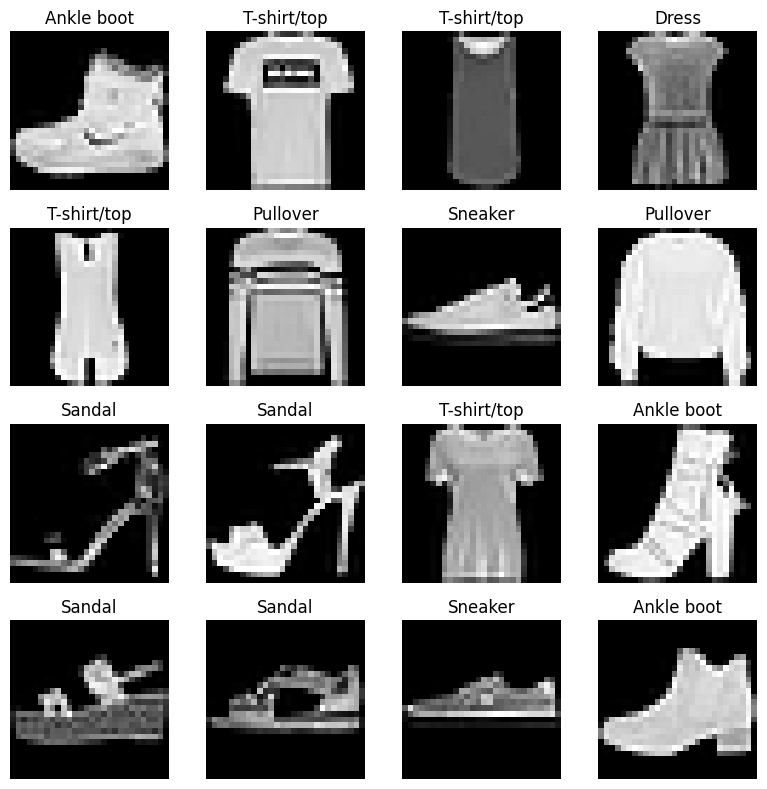

In [3]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
class RBM:
    def __init__(self, n_visible=784, n_hidden=128, learning_rate=0.01):
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        self.learning_rate = learning_rate

        self.W = tf.Variable(
            tf.random.normal([n_visible, n_hidden], mean=0.0, stddev=0.01),
            dtype=tf.float32
        )
        self.vb = tf.Variable(tf.zeros([n_visible]), dtype=tf.float32)
        self.hb = tf.Variable(tf.zeros([n_hidden]), dtype=tf.float32)

    def hidden_prob(self, v):
        return tf.nn.sigmoid(tf.matmul(v, self.W) + self.hb)

    def visible_prob(self, h):
        return tf.nn.sigmoid(tf.matmul(h, tf.transpose(self.W)) + self.vb)

    def sample_prob(self, probs):
        return tf.cast(probs > tf.random.uniform(tf.shape(probs)), tf.float32)

    def contrastive_divergence(self, v0, k=1):
        h0_prob = self.hidden_prob(v0)
        h0_state = self.sample_prob(h0_prob)

        vk = v0
        hk_prob = h0_prob
        hk_state = h0_state

        for _ in range(k):
            vk_prob = self.visible_prob(hk_state)
            vk = self.sample_prob(vk_prob)

            hk_prob = self.hidden_prob(vk)
            hk_state = self.sample_prob(hk_prob)

        batch_size = tf.cast(tf.shape(v0)[0], tf.float32)

        positive_grad = tf.matmul(tf.transpose(v0), h0_prob)
        negative_grad = tf.matmul(tf.transpose(vk), hk_prob)

        self.W.assign_add(self.learning_rate * (positive_grad - negative_grad) / batch_size)
        self.vb.assign_add(self.learning_rate * tf.reduce_mean(v0 - vk, axis=0))
        self.hb.assign_add(self.learning_rate * tf.reduce_mean(h0_prob - hk_prob, axis=0))

        reconstruction_error = tf.reduce_mean(tf.square(v0 - vk_prob))
        return reconstruction_error

    def train(self, data, epochs=10, batch_size=128, k=1):
        dataset = tf.data.Dataset.from_tensor_slices(data)
        dataset = dataset.shuffle(10000).batch(batch_size)

        errors = []

        for epoch in range(epochs):
            epoch_errors = []

            for batch in dataset:
                batch = tf.cast(batch, tf.float32)
                error = self.contrastive_divergence(batch, k)
                epoch_errors.append(error.numpy())

            mean_error = np.mean(epoch_errors)
            errors.append(mean_error)

            print(f"Epoch {epoch + 1}/{epochs} - Reconstruction Error: {mean_error:.4f}")

        return errors

    def transform(self, data):
        data = tf.cast(data, tf.float32)
        return self.hidden_prob(data).numpy()

    def reconstruct(self, data):
        hidden = self.hidden_prob(tf.cast(data, tf.float32))
        visible = self.visible_prob(hidden)
        return visible.numpy()

In [5]:
rbm = RBM(
    n_visible=784,
    n_hidden=128,
    learning_rate=0.01
)

rbm_errors = rbm.train(
    x_train_flat,
    epochs=10,
    batch_size=128,
    k=1
)

Epoch 1/10 - Reconstruction Error: 0.0694
Epoch 2/10 - Reconstruction Error: 0.0511
Epoch 3/10 - Reconstruction Error: 0.0464
Epoch 4/10 - Reconstruction Error: 0.0436
Epoch 5/10 - Reconstruction Error: 0.0419
Epoch 6/10 - Reconstruction Error: 0.0407
Epoch 7/10 - Reconstruction Error: 0.0397
Epoch 8/10 - Reconstruction Error: 0.0389
Epoch 9/10 - Reconstruction Error: 0.0382
Epoch 10/10 - Reconstruction Error: 0.0375


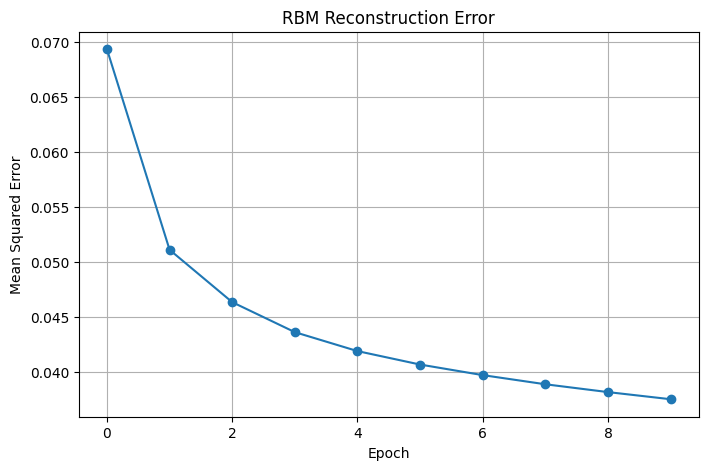

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(rbm_errors, marker="o")
plt.title("RBM Reconstruction Error")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

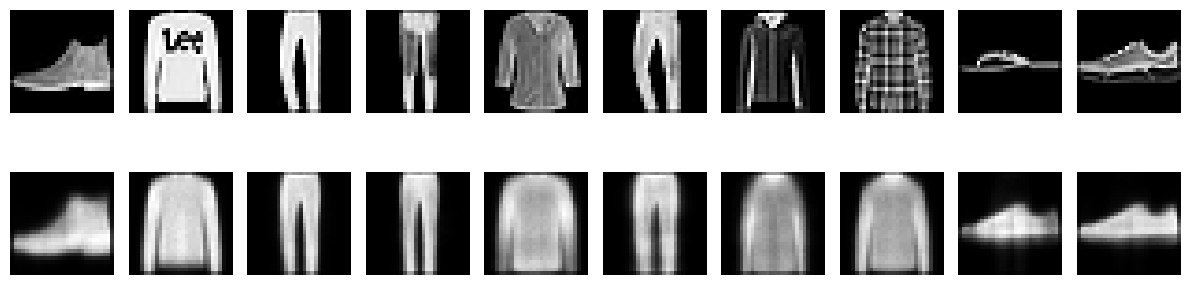

In [7]:
num_images = 10
original = x_test_flat[:num_images]
reconstructed = rbm.reconstruct(original)

plt.figure(figsize=(12, 4))

for i in range(num_images):
    plt.subplot(2, num_images, i + 1)
    plt.imshow(original[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Original")

    plt.subplot(2, num_images, i + 1 + num_images)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.ylabel("Reconstructed")

plt.tight_layout()
plt.show()

In [8]:
x_train_rbm_features = rbm.transform(x_train_flat)
x_test_rbm_features = rbm.transform(x_test_flat)

print("RBM train features shape:", x_train_rbm_features.shape)
print("RBM test features shape:", x_test_rbm_features.shape)

RBM train features shape: (60000, 128)
RBM test features shape: (10000, 128)


In [9]:
mlp_rbm = Sequential([
    Dense(128, activation="relu", input_shape=(128,)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

mlp_rbm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_rbm = mlp_rbm.fit(
    x_train_rbm_features,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6953 - loss: 0.7974 - val_accuracy: 0.7817 - val_loss: 0.5700
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7799 - loss: 0.5788 - val_accuracy: 0.7928 - val_loss: 0.5335
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7945 - loss: 0.5471 - val_accuracy: 0.8084 - val_loss: 0.5063
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8032 - loss: 0.5246 - val_accuracy: 0.8073 - val_loss: 0.4976
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8076 - loss: 0.5130 - val_accuracy: 0.8137 - val_loss: 0.4909
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8115 - loss: 0.5021 - val_accuracy: 0.8165 - val_loss: 0.4829
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8136 - loss: 0.4966 - val_accuracy: 0.8173 - val_loss: 0.4812
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8163 - loss: 0.4909 - val_accuracy: 0.8173 - val_

In [10]:
mlp_raw = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

mlp_raw.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_raw = mlp_raw.fit(
    x_train_flat,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7704 - loss: 0.6520 - val_accuracy: 0.8297 - val_loss: 0.4668
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8409 - loss: 0.4462 - val_accuracy: 0.8487 - val_loss: 0.4123
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8530 - loss: 0.4051 - val_accuracy: 0.8633 - val_loss: 0.3727
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8610 - loss: 0.3816 - val_accuracy: 0.8739 - val_loss: 0.3497
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8686 - loss: 0.3594 - val_accuracy: 0.8713 - val_loss: 0.3533
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8711 - loss: 0.3487 - val_accuracy: 0.8749 - val_loss: 0.3448
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8736 - loss: 0.3419 - val_accuracy: 0.8781 - val_loss: 0.3356
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8789 - loss: 0.3257 - val_accuracy: 0.

In [11]:
rbm_loss, rbm_acc = mlp_rbm.evaluate(x_test_rbm_features, y_test, verbose=0)
raw_loss, raw_acc = mlp_raw.evaluate(x_test_flat, y_test, verbose=0)

print("RBM + MLP Loss:", rbm_loss)
print("RBM + MLP Accuracy:", rbm_acc)

print("Raw Image MLP Loss:", raw_loss)
print("Raw Image MLP Accuracy:", raw_acc)

RBM + MLP Loss: 0.4849618077278137
RBM + MLP Accuracy: 0.8209999799728394
Raw Image MLP Loss: 0.3565913140773773
Raw Image MLP Accuracy: 0.8752999901771545


In [12]:
results = pd.DataFrame({
    "Model": ["RBM Hidden Features + MLP", "Raw Images + MLP"],
    "Test Loss": [rbm_loss, raw_loss],
    "Test Accuracy": [rbm_acc, raw_acc]
})

results

,Model,Test Loss,Test Accuracy
0,RBM Hidden Features + MLP,0.484962,0.8210
1,Raw Images + MLP,0.356591,0.8753


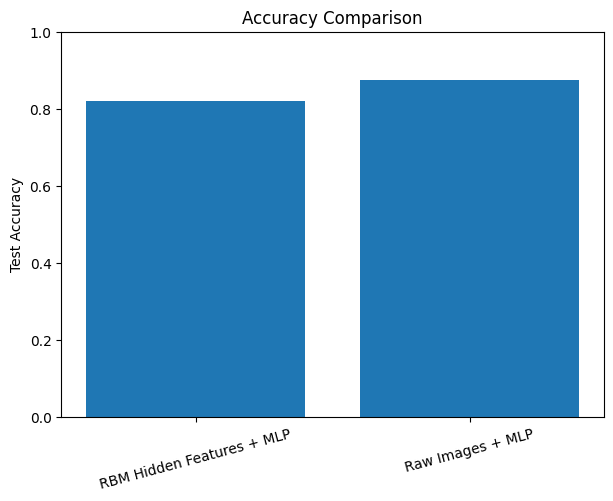

In [13]:
plt.figure(figsize=(7, 5))
plt.bar(results["Model"], results["Test Accuracy"])
plt.title("Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()